# Exploration — Chronicle

**Ce fichier est jetable.** C'est sa fonction, pas son défaut.

Un notebook et un module ne servent pas à la même chose :

| | Notebook | Module (`analytics/*.py`) |
|---|---|---|
| Durée de vie | une session | des mois |
| Ordre d'exécution | dans le désordre, on remonte, on relance | de haut en bas, toujours |
| État | des variables survivent à la cellule qui les a créées | rien ne survit à l'appel |
| Rejouabilité | aucune garantie | `python main.py report` donne le même résultat |

La règle du projet : **on explore ici, on promeut là-bas.**
Une cellule qu'on relance pour la troisième fois en la modifiant à peine
est une fonction qui n'a pas encore été écrite.

> Le piège du notebook : l'état caché. Exécuter les cellules dans le
> désordre laisse des variables d'une version précédente en mémoire. Le
> notebook « marche » et ne marchera plus demain. Avant de croire un
> résultat : *Kernel → Restart & Run All*. S'il ne survit pas, il était faux.


## 0. Mise en route

Le notebook vit dans `notebooks/`, le code dans la racine du projet.
Sans cette ligne, `from analytics import load` échoue : Python cherche
les modules à côté du notebook, pas un cran au-dessus.


In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RACINE))

import pandas as pd
import matplotlib.pyplot as plt

from analytics import load, describe, correlate, quality

# Dans un notebook on VEUT voir les figures ; dans un script, non.
# C'est la difference qui justifie que plots.py force le backend Agg.
%matplotlib inline

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)

print('racine :', RACINE)


racine : c:\Users\everv\Desktop\CodeMastery\PROJECTS\DigitalTwin


## 1. Ce qu'il y a dans la base

Toujours commencer par là. `catalogue()` dit ce qui **existe**,
pas ce qu'on **espère**.


In [2]:
cat = load.catalogue()
print(f'{len(cat)} metriques declarees, {(cat["mesures"] > 0).sum()} avec des mesures')
cat[cat['mesures'] > 0][['granularity', 'mesures', 'premiere', 'derniere']]


52 metriques declarees, 45 avec des mesures


,granularity,mesures,premiere,derniere
code,,,,
activity.active_calories,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.active_duration,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.calories,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.distance,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.goal_completion,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.inactive_duration,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.inactivity_alerts,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
activity.steps,daily,11,2026-08-16 00:00:00+02:00,2026-08-26 00:00:00+02:00
cardio.load,daily,3,2026-08-23 00:00:00+02:00,2026-08-26 00:00:00+02:00


## 2. Le tableau journalier

`v_daily` est une vue SQL : une ligne par jour, une colonne par grandeur.
Le `reindex` de `load.py` a comblé les jours absents par des `NaN` — les
trous sont donc visibles, ce qui est le but.


In [3]:
jours = load.daily()
print(jours.shape)
jours[['sommeil_score', 'hrv', 'fc_nocturne', 'pas', 'calories']].tail(15)


(31, 22)


,sommeil_score,hrv,fc_nocturne,pas,calories
jour,,,,,
2026-08-12,NaN,NaN,NaN,NaN,NaN
2026-08-13,NaN,NaN,NaN,NaN,NaN
2026-08-14,NaN,NaN,NaN,NaN,NaN
2026-08-15,NaN,NaN,NaN,NaN,NaN
2026-08-16,NaN,NaN,NaN,98.0,1599.0
2026-08-17,NaN,NaN,NaN,826.0,1943.0
2026-08-18,86.0,123.0,49.0,4728.0,2661.0
2026-08-19,58.0,93.0,53.0,4246.0,2627.0
2026-08-20,75.0,87.0,56.0,5690.0,2869.0


### Le chiffre qui commande tout le reste

Combien de jours ont **toutes** les grandeurs qu'on veut croiser ?
C'est l'intersection, pas l'union — et elle est toujours plus courte.


In [4]:
coeur = [c for c in quality.COLONNES_COEUR if c in jours.columns]
complets = jours[coeur].dropna()

print(f'fenetre en base : {len(jours)} jours')
print(f'jours complets  : {len(complets)}   <-- le n reel')
complets


fenetre en base : 31 jours
jours complets  : 8   <-- le n reel


,sommeil_score,hrv,fc_nocturne,pas,calories
jour,,,,,
2026-08-18,86.0,123.0,49.0,4728.0,2661.0
2026-08-19,58.0,93.0,53.0,4246.0,2627.0
2026-08-20,75.0,87.0,56.0,5690.0,2869.0
2026-08-21,52.0,57.0,72.0,13004.0,3602.0
2026-08-22,64.0,70.0,67.0,2573.0,2419.0
2026-08-23,83.0,84.0,61.0,5624.0,2721.0
2026-08-24,73.0,84.0,59.0,2000.0,1972.0
2026-08-26,70.0,99.0,50.0,264.0,771.0


## 3. Une question, posée avant de regarder

L'ordre compte. Poser la question d'abord, puis regarder, est une
démarche. Regarder puis choisir ce qui ressort est du *p-hacking*,
et personne ne le fait exprès.

**Question :** un jour très actif dégrade-t-il la récupération de la
nuit *suivante* ?

Le décalage n'est pas un réglage : c'est l'hypothèse causale elle-même.
Sans lui on demanderait si l'activité du mardi influence la nuit du
lundi au mardi — c'est-à-dire une nuit déjà passée.


In [5]:
test = correlate.tester(jours['pas'], jours['hrv'], 'pas', 'hrv', decalage=1)

if test is None:
    print('pas assez de points communs')
else:
    print(f'r   = {test.r:+.2f}')
    print(f'n   = {test.n}')
    print(f'p   = {test.p:.4f}')
    print()
    print('Rappel : p est la probabilite de voir ce r SI aucun lien',
          "n'existait.")
    print("Ce n'est pas la probabilite que le lien existe.")


r   = -0.85
n   = 8
p   = 0.0075

Rappel : p est la probabilite de voir ce r SI aucun lien n'existait.
Ce n'est pas la probabilite que le lien existe.


### Et le nuage de points, qui vaut mieux que le coefficient

Sur 7 points, l'œil voit ce qu'un `r` cache : un seul jour peut
porter toute la corrélation. Chaque point est daté pour ça.


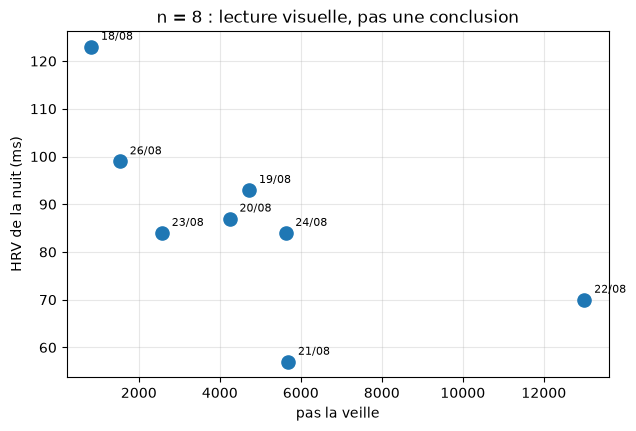

In [6]:
paire = pd.DataFrame({
    'pas_veille': jours['pas'].shift(1),
    'hrv': jours['hrv'],
}).dropna()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(paire['pas_veille'], paire['hrv'], s=90, zorder=3)

for jour, ligne in paire.iterrows():
    ax.annotate(f'{jour:%d/%m}', (ligne['pas_veille'], ligne['hrv']),
                textcoords='offset points', xytext=(7, 5), fontsize=8)

ax.set_xlabel('pas la veille')
ax.set_ylabel('HRV de la nuit (ms)')
ax.set_title(f'n = {len(paire)} : lecture visuelle, pas une conclusion')
ax.grid(alpha=0.3)
plt.show()


## 4. Calibrer son intuition sur du bruit pur

La p-value de `correlate.py` est calculee a la main (voir le ROADMAP :
scipy est bloque sur cette machine). Deux facons de la verifier : la
comparer a la table de Student - c'est fait, ecart maximal 2e-5 - ou la
mettre a l'epreuve par simulation.

La simulation repond en plus a une question que la table ne repond pas :
**a quoi ressemble le hasard, avec MON n ?**

In [7]:
import numpy as np

# Combien de paires SANS AUCUN LIEN ressortent "significatives" ?
rng = np.random.default_rng(42)
n = int(jours[["pas", "hrv"]].dropna().shape[0])
essais = 2000

faux_positifs = 0
r_max = 0.0

for _ in range(essais):
    a = pd.Series(rng.normal(size=n))
    b = pd.Series(rng.normal(size=n))
    resultat = correlate.tester(a, b, "bruit_a", "bruit_b")

    if resultat is None:
        continue
    if resultat.p < 0.05:
        faux_positifs += 1
    r_max = max(r_max, abs(resultat.r))

print(f"n = {n}, {essais} paires de bruit pur")
print(f"  {faux_positifs} significatives a p < 0.05  "
      f"({faux_positifs / essais:.1%})")
print(f"  |r| le plus fort obtenu par pur hasard : {r_max:.2f}")
print()
print("Le taux doit tomber vers 5% : c'est la DEFINITION du seuil, et")
print("ca valide l'implementation maison de la p-value.")
print()
print("Le second chiffre est le plus utile : c'est le r qu'il faut")
print("battre pour meriter le moindre interet, avec ce n-la.")

n = 8, 2000 paires de bruit pur
  102 significatives a p < 0.05  (5.1%)
  |r| le plus fort obtenu par pur hasard : 0.98

Le taux doit tomber vers 5% : c'est la DEFINITION du seuil, et
ca valide l'implementation maison de la p-value.

Le second chiffre est le plus utile : c'est le r qu'il faut
battre pour meriter le moindre interet, avec ce n-la.


## 4. Bac à sable

À partir d'ici, tout est à toi. Quelques pistes :

- `load.observations('heart_rate')` — les 28 000 mesures brutes,
  en série temporelle. Essaie `.resample('1h').mean()`.
- `load.sleep()` — une ligne par nuit, avec heures de coucher/lever.
- `describe.aberrantes(jours['pas'])` — la règle de Tukey.
- `correlate.tendance(jours['hrv'])` — la grandeur dérive-t-elle ?

**Quand une cellule devient utile, elle sort d'ici.** Elle devient une
fonction dans `analytics/`, avec un nom, une docstring et une place
dans le rapport. C'est le seul chemin par lequel une trouvaille
survit à la session.


In [8]:
# À toi.

